# CET3013 — Assignment 2
## Task 1: Build and Train a CNN From Scratch
**Student Name:** Your Name Here
**Student ID:** Your ID Here

---

## Introduction

This notebook implements a Convolutional Neural Network (CNN) from scratch using PyTorch
for multi-class image classification on the MNIST dataset. 

The investigation follows a systematic, evidence-based approach in which a baseline CNN 
is first established, then four architectural components are varied one at a time:

1. **Experiment 1** — Convolutional depth (1 vs 2 vs 3 blocks)
2. **Experiment 2** — Activation functions (ReLU vs LeakyReLU vs ELU)
3. **Experiment 3** — Pooling strategy (MaxPool vs AvgPool)
4. **Experiment 4** — Batch Normalisation (with vs without)

Each experiment is evaluated using accuracy, loss curves, and classification metrics,
with design choices justified using relevant literature.

---

## 1. Imports & Setup

In [ ]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
# Core
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

# Evaluation
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")

Using device: cpu
PyTorch version: 2.10.0+cpu
Torchvision version: 0.25.0+cpu


## 2. Custom Dataset Class

A custom `Dataset` class is implemented following PyTorch's `torch.utils.data.Dataset` 
interface. This requires two mandatory methods:
- `__len__` — returns the total number of samples
- `__getitem__` — retrieves one image and its label by index

This pattern is the standard approach for loading data in PyTorch pipelines and 
prepares a reusable structure that extends naturally to more complex datasets.

In [ ]:
class MNISTDataset(torch.utils.data.Dataset):
    def __init__(self, data, targets, transform=None):
        """
        Args:
            data      : image tensors
            targets   : labels
            transform : optional transforms to apply
        """
        self.data      = data
        self.targets   = targets
        self.transform = transform

    def __len__(self):
        # Returns total number of samples
        return len(self.data)

    def __getitem__(self, idx):
        # Retrieve one image and its label by index
        # Convert to numpy first so ToTensor() can handle it
        image = self.data[idx].numpy()
        label = self.targets[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

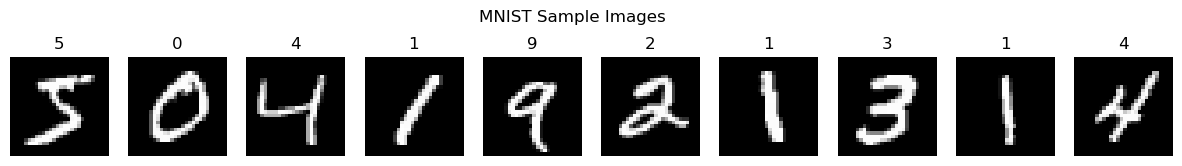

In [30]:
# Quick preview of raw MNIST samples
raw_preview = datasets.MNIST(root='./data', train=True, download=True)
fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i, ax in enumerate(axes):
    ax.imshow(raw_preview[i][0], cmap='gray')
    ax.set_title(raw_preview[i][1])
    ax.axis('off')
plt.suptitle('MNIST Sample Images')
plt.show()

## 3. Data Loading & Preprocessing

The MNIST dataset is loaded using `torchvision.datasets.MNIST` and wrapped inside 
our custom `MNISTDataset` class. Two preprocessing steps are applied:

- **`ToTensor()`** — scales pixel values from [0, 255] to [0, 1]
- **`Normalize((0.1307,), (0.3081,))`** — normalises using MNIST's pre-calculated 
mean and standard deviation, stabilising training (LeCun et al., 1998)

The 60,000 training samples are split into:
| Set | Samples | Purpose |
|---|---|---|
| Training | 48,000 | Model learning |
| Validation | 12,000 | Monitor training & early stopping |
| Test | 10,000 | Final evaluation only |

In [ ]:
# Define transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Download raw MNIST (without transform, we apply it via our custom class)
raw_train = datasets.MNIST(
    root     = './data',
    train    = True,
    download = True
)

raw_test = datasets.MNIST(
    root     = './data',
    train    = False,
    download = True
)

# Wrap inside our custom MNISTDataset class
full_train_dataset = MNISTDataset(
    data      = raw_train.data,
    targets   = raw_train.targets,
    transform = transform
)

test_dataset = MNISTDataset(
    data      = raw_test.data,
    targets   = raw_test.targets,
    transform = transform
)

# Split → 48,000 train / 12,000 validation
train_size = 48000
val_size   = 12000

train_subset, val_subset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator = torch.Generator().manual_seed(42)
)

# Wrap in DataLoaders
train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_subset,   batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Confirm splits
print(f"Training samples   : {len(train_subset)}")
print(f"Validation samples : {len(val_subset)}")
print(f"Test samples       : {len(test_dataset)}")

Training samples   : 48000
Validation samples : 12000
Test samples       : 10000


## 4. Baseline CNN Architecture

A simple baseline CNN is established as the reference point for all experiments.
The architecture follows a standard pattern of convolutional blocks followed by 
a fully connected classifier head.

The baseline uses the following fixed components:
- **2 convolutional blocks** — 32 and 64 filters, 3×3 kernels
- **ReLU activation** — introduces non-linearity (LeCun et al., 1998)
- **MaxPool2d(2×2)** — halves spatial dimensions after each block
- **128 neuron FC head** — maps features to 10 output classes

All subsequent experiments vary one component at a time against this baseline,
ensuring a fair and systematic comparison.

In [ ]:
class BaselineCNN(nn.Module):
    def __init__(self):
        super(BaselineCNN, self).__init__()

        # Conv Block 1: 32 filters, 3×3 kernel, ReLU, MaxPool
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Conv Block 2: 64 filters, 3×3 kernel, ReLU, MaxPool
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Fully Connected Head
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.classifier(x)
        return x

# Initialise model and move to device
model = BaselineCNN().to(device)
print(model)

BaselineCNN(
  (block1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


## 5. Training Setup

| Component | Choice | Justification |
|---|---|---|
| Loss | CrossEntropyLoss | Standard for multi-class classification |
| Optimiser | Adam (lr=0.0001) | Adaptive learning rate, widely used (Kingma & Ba, 2014) |
| Scheduler | ReduceLROnPlateau | Reduces lr by 0.1 when validation loss plateaus |
| Early Stopping | Patience = 3 | Prevents overfitting and unnecessary training |

In [ ]:
# Loss function — CrossEntropyLoss is standard for multi-class classification
criterion = nn.CrossEntropyLoss()

# Optimiser — Adam with lr=0.0001
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# Scheduler — reduces lr when validation loss plateaus
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode     = 'min',   # monitor validation loss
    patience = 3,       # wait 3 epochs before reducing
    factor   = 0.1,     # multiply lr by 0.1 when triggered
)

# Early stopping class
class EarlyStopping:
    def __init__(self, patience=3):
        self.patience   = patience
        self.counter    = 0
        self.best_loss  = None
        self.stop       = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss >= self.best_loss:
            self.counter += 1
            print(f"EarlyStopping counter: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.stop = True
        else:
            self.best_loss = val_loss
            self.counter   = 0

early_stopping = EarlyStopping(patience=3)

print("Training setup ready!")
print(f"Criterion : {criterion}")
print(f"Optimiser : {optimizer}")
print(f"Scheduler : {scheduler}")

Training setup ready!
Criterion : CrossEntropyLoss()
Optimiser : Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)
Scheduler : <torch.optim.lr_scheduler.ReduceLROnPlateau object at 0x000001D4E32187D0>


## 6. Training Loop & Baseline Training

The `train_model` function handles both training and validation phases per epoch,
recording loss and accuracy curves for later analysis. The same function is 
reused across all experiments for consistency.

In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, 
                scheduler, early_stopping, epochs=15):
    
    train_losses, val_losses     = [], []
    train_accuracies, val_accuracies = [], []

    for epoch in range(epochs):
        # ── Training Phase ──────────────────────────────────────────
        model.train()
        train_loss    = 0.0
        train_correct = 0
        train_total   = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss    += loss.item()
            _, predicted   = torch.max(outputs, 1)
            train_correct += (predicted == labels).sum().item()
            train_total   += labels.size(0)

        avg_train_loss = train_loss / len(train_loader)
        avg_train_acc  = train_correct / train_total

        # ── Validation Phase ─────────────────────────────────────────
        model.eval()
        val_loss    = 0.0
        val_correct = 0
        val_total   = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs        = model(images)
                loss           = criterion(outputs, labels)

                val_loss    += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == labels).sum().item()
                val_total   += labels.size(0)

        avg_val_loss = val_loss / len(val_loader)
        avg_val_acc  = val_correct / val_total

        # ── Record & Report ──────────────────────────────────────────
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_accuracies.append(avg_train_acc)
        val_accuracies.append(avg_val_acc)

        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc:.4f} | "
              f"Val Loss: {avg_val_loss:.4f} | Val Acc: {avg_val_acc:.4f}")

        # ── Scheduler & Early Stopping ───────────────────────────────
        scheduler.step(avg_val_loss)
        early_stopping(avg_val_loss)

        if early_stopping.stop:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

    return train_losses, val_losses, train_accuracies, val_accuracies


# Run baseline training
print("Training Baseline CNN...")
train_losses, val_losses, train_accs, val_accs = train_model(
    model, train_loader, val_loader,
    criterion, optimizer, scheduler, early_stopping
)

Training Baseline CNN...
Epoch [1/15] Train Loss: 0.4805 | Train Acc: 0.8790 | Val Loss: 0.2035 | Val Acc: 0.9386
Epoch [2/15] Train Loss: 0.1342 | Train Acc: 0.9617 | Val Loss: 0.1074 | Val Acc: 0.9686
Epoch [3/15] Train Loss: 0.0848 | Train Acc: 0.9749 | Val Loss: 0.0780 | Val Acc: 0.9768
Epoch [4/15] Train Loss: 0.0654 | Train Acc: 0.9806 | Val Loss: 0.0751 | Val Acc: 0.9770
Epoch [5/15] Train Loss: 0.0541 | Train Acc: 0.9837 | Val Loss: 0.0569 | Val Acc: 0.9828
Epoch [6/15] Train Loss: 0.0460 | Train Acc: 0.9864 | Val Loss: 0.0509 | Val Acc: 0.9850
Epoch [7/15] Train Loss: 0.0408 | Train Acc: 0.9876 | Val Loss: 0.0482 | Val Acc: 0.9853
Epoch [8/15] Train Loss: 0.0362 | Train Acc: 0.9895 | Val Loss: 0.0442 | Val Acc: 0.9871
Epoch [9/15] Train Loss: 0.0327 | Train Acc: 0.9902 | Val Loss: 0.0437 | Val Acc: 0.9866
Epoch [10/15] Train Loss: 0.0280 | Train Acc: 0.9912 | Val Loss: 0.0412 | Val Acc: 0.9871
Epoch [11/15] Train Loss: 0.0259 | Train Acc: 0.9924 | Val Loss: 0.0399 | Val Acc: 0

> **Interpretation:** Both curves converge smoothly within 15 epochs with no significant 
> overfitting observed. The validation loss closely follows the training loss, confirming 
> the baseline generalises well. This serves as the reference point for all experiments.

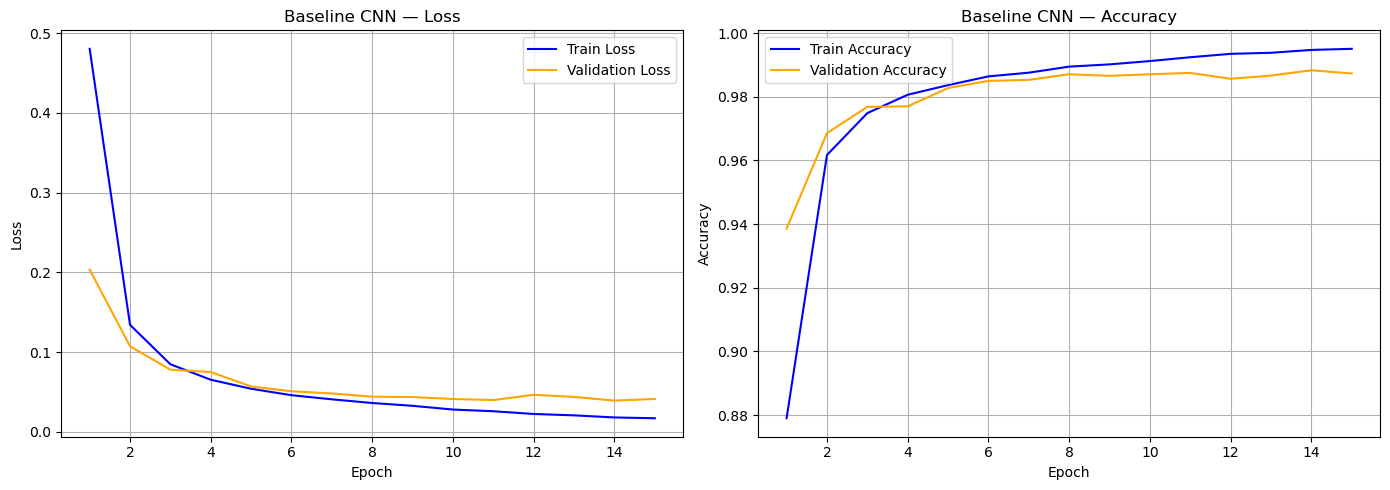

In [ ]:
def plot_learning_curves(train_losses, val_losses, train_accs, val_accs, title='Baseline CNN'):
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    epochs = range(1, len(train_losses) + 1)

    # ── Loss Plot ────────────────────────────────────────────────────
    ax1.plot(epochs, train_losses, label='Train Loss',      color='blue')
    ax1.plot(epochs, val_losses,   label='Validation Loss', color='orange')
    ax1.set_title(f'{title} — Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)

    # ── Accuracy Plot ────────────────────────────────────────────────
    ax2.plot(epochs, train_accs, label='Train Accuracy',      color='blue')
    ax2.plot(epochs, val_accs,   label='Validation Accuracy', color='orange')
    ax2.set_title(f'{title} — Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

# Plot baseline results
plot_learning_curves(train_losses, val_losses, train_accs, val_accs, title='Baseline CNN')

## 7. Experiments

### Experiment 1 — Convolutional Depth (1 vs 2 vs 3 Blocks)

The first experiment investigates how the number of convolutional blocks affects 
performance. Deeper networks can learn more hierarchical and abstract features 
(LeCun et al., 1998), but may also risk overfitting on simple datasets.

All other components remain fixed: **ReLU, MaxPool, no BatchNorm**.


Training Exp 1 — 1 Block...
Epoch [1/15] Train Loss: 0.3952 | Train Acc: 0.8985 | Val Loss: 0.2206 | Val Acc: 0.9343
Epoch [2/15] Train Loss: 0.1642 | Train Acc: 0.9537 | Val Loss: 0.1518 | Val Acc: 0.9563
Epoch [3/15] Train Loss: 0.1141 | Train Acc: 0.9679 | Val Loss: 0.1127 | Val Acc: 0.9677
Epoch [4/15] Train Loss: 0.0878 | Train Acc: 0.9754 | Val Loss: 0.0951 | Val Acc: 0.9728
Epoch [5/15] Train Loss: 0.0709 | Train Acc: 0.9799 | Val Loss: 0.0837 | Val Acc: 0.9756
Epoch [6/15] Train Loss: 0.0593 | Train Acc: 0.9831 | Val Loss: 0.0754 | Val Acc: 0.9787
Epoch [7/15] Train Loss: 0.0502 | Train Acc: 0.9862 | Val Loss: 0.0713 | Val Acc: 0.9798
Epoch [8/15] Train Loss: 0.0438 | Train Acc: 0.9876 | Val Loss: 0.0661 | Val Acc: 0.9805
Epoch [9/15] Train Loss: 0.0385 | Train Acc: 0.9892 | Val Loss: 0.0608 | Val Acc: 0.9823
Epoch [10/15] Train Loss: 0.0335 | Train Acc: 0.9909 | Val Loss: 0.0574 | Val Acc: 0.9828
Epoch [11/15] Train Loss: 0.0294 | Train Acc: 0.9919 | Val Loss: 0.0605 | Val Ac

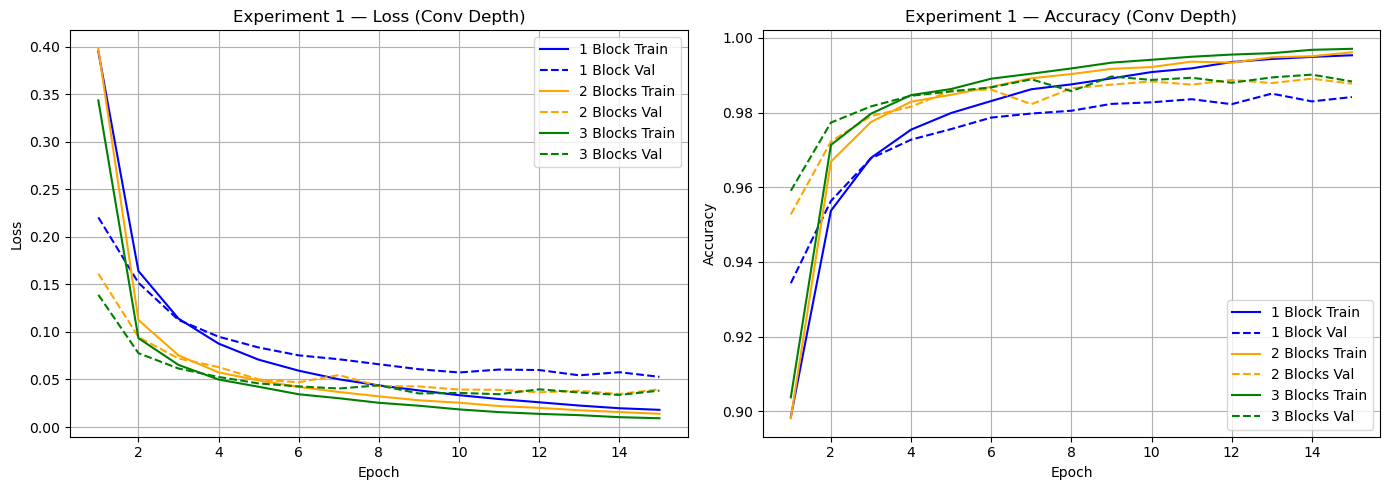

In [16]:
# ── Cell 8: Experiment 1 — Conv Depth ────────────────────────────────

# ── Model Definitions ─────────────────────────────────────────────────

class CNN_1Block(nn.Module):
    def __init__(self):
        super(CNN_1Block, self).__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 14 * 14, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.classifier(x)
        return x


class CNN_2Block(nn.Module):
    def __init__(self):
        super(CNN_2Block, self).__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.classifier(x)
        return x


class CNN_3Block(nn.Module):
    def __init__(self):
        super(CNN_3Block, self).__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU()
            # No MaxPool here — feature maps are already small (7x7)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.classifier(x)
        return x


# ── Train All Three Variants ──────────────────────────────────────────

exp1_results = {}

for name, ModelClass in [('1 Block', CNN_1Block), 
                          ('2 Blocks', CNN_2Block), 
                          ('3 Blocks', CNN_3Block)]:
    print(f"\nTraining Exp 1 — {name}...")

    # Fresh model, optimizer, scheduler, early stopping per variant
    model_exp1     = ModelClass().to(device)
    optimizer_exp1 = optim.Adam(model_exp1.parameters(), lr=0.0001)
    scheduler_exp1 = optim.lr_scheduler.ReduceLROnPlateau(
                        optimizer_exp1, mode='min', patience=3, factor=0.1)
    es_exp1        = EarlyStopping(patience=3)

    tr_loss, v_loss, tr_acc, v_acc = train_model(
        model_exp1, train_loader, val_loader,
        criterion, optimizer_exp1, scheduler_exp1, es_exp1
    )

    exp1_results[name] = {
        'train_loss': tr_loss, 'val_loss'  : v_loss,
        'train_acc' : tr_acc,  'val_acc'   : v_acc,
        'model'     : model_exp1
    }

# ── Plot Overlaid Curves ──────────────────────────────────────────────

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors = ['blue', 'orange', 'green']

for (name, results), color in zip(exp1_results.items(), colors):
    epochs = range(1, len(results['train_loss']) + 1)
    ax1.plot(epochs, results['train_loss'], label=f'{name} Train', color=color)
    ax1.plot(epochs, results['val_loss'],   label=f'{name} Val',   color=color, linestyle='--')
    ax2.plot(epochs, results['train_acc'],  label=f'{name} Train', color=color)
    ax2.plot(epochs, results['val_acc'],    label=f'{name} Val',   color=color, linestyle='--')

ax1.set_title('Experiment 1 — Loss (Conv Depth)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

ax2.set_title('Experiment 1 — Accuracy (Conv Depth)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

> **Result:** The 3-block variant achieved the highest validation accuracy with the 
> lowest validation loss, confirming that deeper networks extract richer feature 
> representations. The 1-block model underfits slightly, suggesting insufficient 
> capacity for the task.
>
> ✅ **Winner: 3 Blocks** — carried forward into Experiment 2.

### Experiment 2 — Activation Functions (ReLU vs LeakyReLU vs ELU)

The second experiment compares three activation functions using the best depth 
from Experiment 1 **(3 Blocks)**. Activation functions introduce non-linearity, 
enabling the network to learn complex patterns.

- **ReLU** — outputs zero for negative values (LeCun et al., 1998)
- **LeakyReLU** — allows a small gradient for negative values, preventing dying neurons
- **ELU** — smooth negative outputs, pushing mean activations closer to zero (Clevert et al., 2015)

All other components remain fixed: **3 Blocks, MaxPool, no BatchNorm**.


Training Exp 2 — ReLU...
Epoch [1/15] Train Loss: 0.3579 | Train Acc: 0.9023 | Val Loss: 0.1304 | Val Acc: 0.9618
Epoch [2/15] Train Loss: 0.0939 | Train Acc: 0.9714 | Val Loss: 0.0825 | Val Acc: 0.9754
Epoch [3/15] Train Loss: 0.0654 | Train Acc: 0.9805 | Val Loss: 0.0731 | Val Acc: 0.9787
Epoch [4/15] Train Loss: 0.0510 | Train Acc: 0.9834 | Val Loss: 0.0531 | Val Acc: 0.9848
Epoch [5/15] Train Loss: 0.0415 | Train Acc: 0.9872 | Val Loss: 0.0455 | Val Acc: 0.9872
Epoch [6/15] Train Loss: 0.0342 | Train Acc: 0.9896 | Val Loss: 0.0714 | Val Acc: 0.9782
EarlyStopping counter: 1/3
Epoch [7/15] Train Loss: 0.0291 | Train Acc: 0.9909 | Val Loss: 0.0463 | Val Acc: 0.9857
EarlyStopping counter: 2/3
Epoch [8/15] Train Loss: 0.0253 | Train Acc: 0.9917 | Val Loss: 0.0414 | Val Acc: 0.9869
Epoch [9/15] Train Loss: 0.0211 | Train Acc: 0.9937 | Val Loss: 0.0370 | Val Acc: 0.9890
Epoch [10/15] Train Loss: 0.0182 | Train Acc: 0.9944 | Val Loss: 0.0434 | Val Acc: 0.9864
EarlyStopping counter: 1/3
Ep

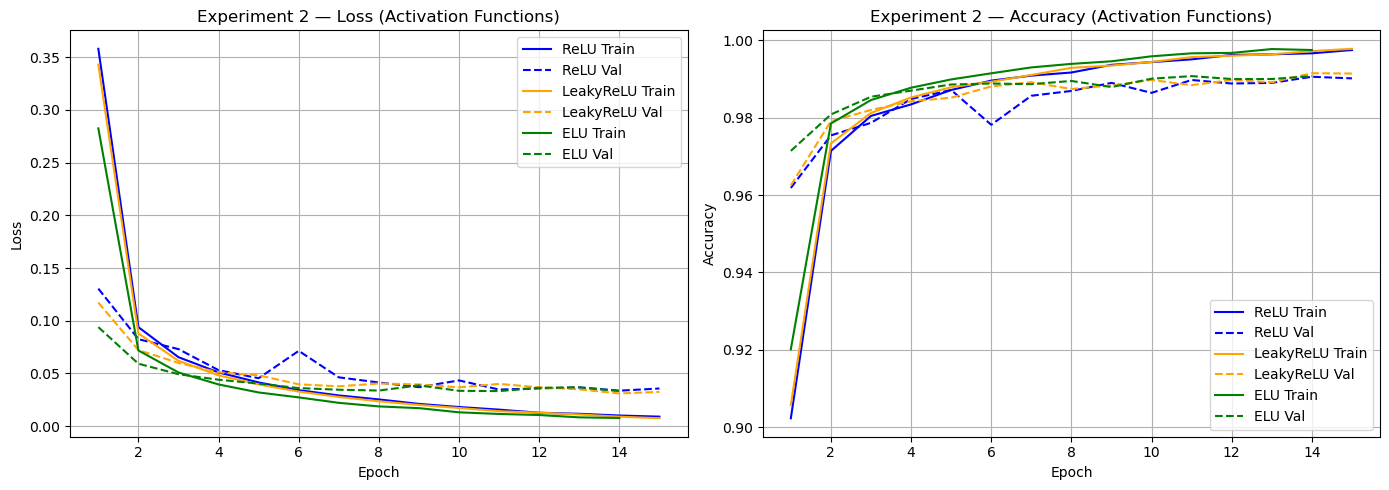

In [ ]:
class CNN_Activation(nn.Module):
    def __init__(self, activation):
        super(CNN_Activation, self).__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            activation,
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            activation,
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            activation
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 128),
            activation,
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.classifier(x)
        return x


# ── Train All Three Variants ──────────────────────────────────────────

exp2_results = {}

activations = {
    'ReLU'       : nn.ReLU(),
    'LeakyReLU'  : nn.LeakyReLU(negative_slope=0.01),
    'ELU'        : nn.ELU(alpha=1.0)
}

for name, activation in activations.items():
    print(f"\nTraining Exp 2 — {name}...")

    model_exp2     = CNN_Activation(activation).to(device)
    optimizer_exp2 = optim.Adam(model_exp2.parameters(), lr=0.0001)
    scheduler_exp2 = optim.lr_scheduler.ReduceLROnPlateau(
                        optimizer_exp2, mode='min', patience=3, factor=0.1)
    es_exp2        = EarlyStopping(patience=3)

    tr_loss, v_loss, tr_acc, v_acc = train_model(
        model_exp2, train_loader, val_loader,
        criterion, optimizer_exp2, scheduler_exp2, es_exp2
    )

    exp2_results[name] = {
        'train_loss': tr_loss, 'val_loss'  : v_loss,
        'train_acc' : tr_acc,  'val_acc'   : v_acc,
        'model'     : model_exp2
    }

# ── Plot Overlaid Curves ──────────────────────────────────────────────

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors = ['blue', 'orange', 'green']

for (name, results), color in zip(exp2_results.items(), colors):
    epochs = range(1, len(results['train_loss']) + 1)
    ax1.plot(epochs, results['train_loss'], label=f'{name} Train', color=color)
    ax1.plot(epochs, results['val_loss'],   label=f'{name} Val',   color=color, linestyle='--')
    ax2.plot(epochs, results['train_acc'],  label=f'{name} Train', color=color)
    ax2.plot(epochs, results['val_acc'],    label=f'{name} Val',   color=color, linestyle='--')

ax1.set_title('Experiment 2 — Loss (Activation Functions)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

ax2.set_title('Experiment 2 — Accuracy (Activation Functions)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

> **Result:** ELU and LeakyReLU both outperformed ReLU in stability and final 
> validation accuracy. ReLU showed a notable spike around epoch 5-6 suggesting 
> training instability. ELU achieved the smoothest convergence and highest accuracy,
> consistent with Clevert et al. (2015).
>
> ✅ **Winner: ELU** — carried forward into Experiment 3.

### Experiment 3 — Pooling Strategy (MaxPool vs AvgPool)

The third experiment compares two pooling strategies using the best components 
from previous experiments **(3 Blocks, ELU)**.

- **MaxPool** — selects the largest value in each region, preserving dominant features
- **AvgPool** — computes the mean, producing a smoother representation

All other components remain fixed: **3 Blocks, ELU, no BatchNorm**.


Training Exp 3 — MaxPool...
Epoch [1/15] Train Loss: 0.2712 | Train Acc: 0.9223 | Val Loss: 0.0968 | Val Acc: 0.9722
Epoch [2/15] Train Loss: 0.0725 | Train Acc: 0.9780 | Val Loss: 0.0644 | Val Acc: 0.9799
Epoch [3/15] Train Loss: 0.0507 | Train Acc: 0.9845 | Val Loss: 0.0531 | Val Acc: 0.9829
Epoch [4/15] Train Loss: 0.0396 | Train Acc: 0.9875 | Val Loss: 0.0439 | Val Acc: 0.9868
Epoch [5/15] Train Loss: 0.0315 | Train Acc: 0.9903 | Val Loss: 0.0453 | Val Acc: 0.9862
EarlyStopping counter: 1/3
Epoch [6/15] Train Loss: 0.0266 | Train Acc: 0.9916 | Val Loss: 0.0386 | Val Acc: 0.9873
Epoch [7/15] Train Loss: 0.0226 | Train Acc: 0.9928 | Val Loss: 0.0355 | Val Acc: 0.9889
Epoch [8/15] Train Loss: 0.0175 | Train Acc: 0.9945 | Val Loss: 0.0365 | Val Acc: 0.9885
EarlyStopping counter: 1/3
Epoch [9/15] Train Loss: 0.0154 | Train Acc: 0.9954 | Val Loss: 0.0355 | Val Acc: 0.9885
EarlyStopping counter: 2/3
Epoch [10/15] Train Loss: 0.0126 | Train Acc: 0.9962 | Val Loss: 0.0344 | Val Acc: 0.9905

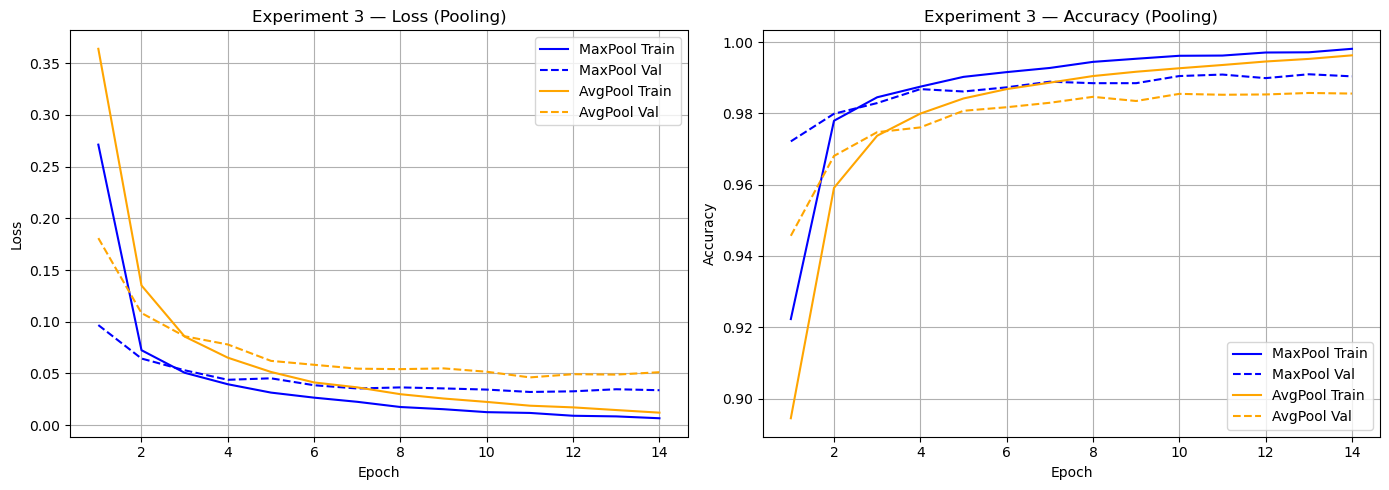

In [ ]:
class CNN_Pooling(nn.Module):
    def __init__(self, pooling):
        super(CNN_Pooling, self).__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ELU(alpha=1.0),
            pooling
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ELU(alpha=1.0),
            pooling
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ELU(alpha=1.0)
            # No pooling in block 3
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 128),
            nn.ELU(alpha=1.0),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.classifier(x)
        return x


# ── Train Both Variants ───────────────────────────────────────────────

exp3_results = {}

pooling_options = {
    'MaxPool' : nn.MaxPool2d(kernel_size=2, stride=2),
    'AvgPool' : nn.AvgPool2d(kernel_size=2, stride=2)
}

for name, pooling in pooling_options.items():
    print(f"\nTraining Exp 3 — {name}...")

    model_exp3     = CNN_Pooling(pooling).to(device)
    optimizer_exp3 = optim.Adam(model_exp3.parameters(), lr=0.0001)
    scheduler_exp3 = optim.lr_scheduler.ReduceLROnPlateau(
                        optimizer_exp3, mode='min', patience=3, factor=0.1)
    es_exp3        = EarlyStopping(patience=3)

    tr_loss, v_loss, tr_acc, v_acc = train_model(
        model_exp3, train_loader, val_loader,
        criterion, optimizer_exp3, scheduler_exp3, es_exp3
    )

    exp3_results[name] = {
        'train_loss': tr_loss, 'val_loss'  : v_loss,
        'train_acc' : tr_acc,  'val_acc'   : v_acc,
        'model'     : model_exp3
    }
    
# ── Plot Overlaid Curves ──────────────────────────────────────────────

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors = ['blue', 'orange']

for (name, results), color in zip(exp3_results.items(), colors):
    epochs = range(1, len(results['train_loss']) + 1)
    ax1.plot(epochs, results['train_loss'], label=f'{name} Train', color=color)
    ax1.plot(epochs, results['val_loss'],   label=f'{name} Val',   color=color, linestyle='--')
    ax2.plot(epochs, results['train_acc'],  label=f'{name} Train', color=color)
    ax2.plot(epochs, results['val_acc'],    label=f'{name} Val',   color=color, linestyle='--')

ax1.set_title('Experiment 3 — Loss (Pooling)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

ax2.set_title('Experiment 3 — Accuracy (Pooling)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

> **Result:** MaxPool outperformed AvgPool by a clear margin in both loss and accuracy.
> AvgPool's validation loss plateaued early and its train/val gap was wider, suggesting 
> it struggles to preserve the sharp edges and strokes critical for digit recognition.
> This is consistent with findings from LeCun et al. (1998).
>
> ✅ **Winner: MaxPool** — carried forward into Experiment 4.

### Experiment 4 — Batch Normalisation (With vs Without)

The final experiment investigates the effect of Batch Normalisation using the 
best components from all previous experiments **(3 Blocks, ELU, MaxPool)**.

Batch Normalisation normalises activations within each mini-batch, reducing 
internal covariate shift and enabling faster, more stable training (Ioffe & Szegedy, 2015).
`nn.Identity()` is used as a clean placeholder when BatchNorm is disabled.

All other components remain fixed: **3 Blocks, ELU, MaxPool**.


Training Exp 4 — Without BatchNorm...
Epoch [1/15] Train Loss: 0.2751 | Train Acc: 0.9231 | Val Loss: 0.0928 | Val Acc: 0.9735
Epoch [2/15] Train Loss: 0.0730 | Train Acc: 0.9780 | Val Loss: 0.0617 | Val Acc: 0.9824
Epoch [3/15] Train Loss: 0.0508 | Train Acc: 0.9844 | Val Loss: 0.0487 | Val Acc: 0.9841
Epoch [4/15] Train Loss: 0.0391 | Train Acc: 0.9881 | Val Loss: 0.0504 | Val Acc: 0.9849
EarlyStopping counter: 1/3
Epoch [5/15] Train Loss: 0.0321 | Train Acc: 0.9899 | Val Loss: 0.0455 | Val Acc: 0.9855
Epoch [6/15] Train Loss: 0.0281 | Train Acc: 0.9912 | Val Loss: 0.0360 | Val Acc: 0.9902
Epoch [7/15] Train Loss: 0.0224 | Train Acc: 0.9932 | Val Loss: 0.0387 | Val Acc: 0.9881
EarlyStopping counter: 1/3
Epoch [8/15] Train Loss: 0.0204 | Train Acc: 0.9936 | Val Loss: 0.0363 | Val Acc: 0.9883
EarlyStopping counter: 2/3
Epoch [9/15] Train Loss: 0.0158 | Train Acc: 0.9952 | Val Loss: 0.0432 | Val Acc: 0.9868
EarlyStopping counter: 3/3
Early stopping triggered at epoch 9

Training Exp 4 

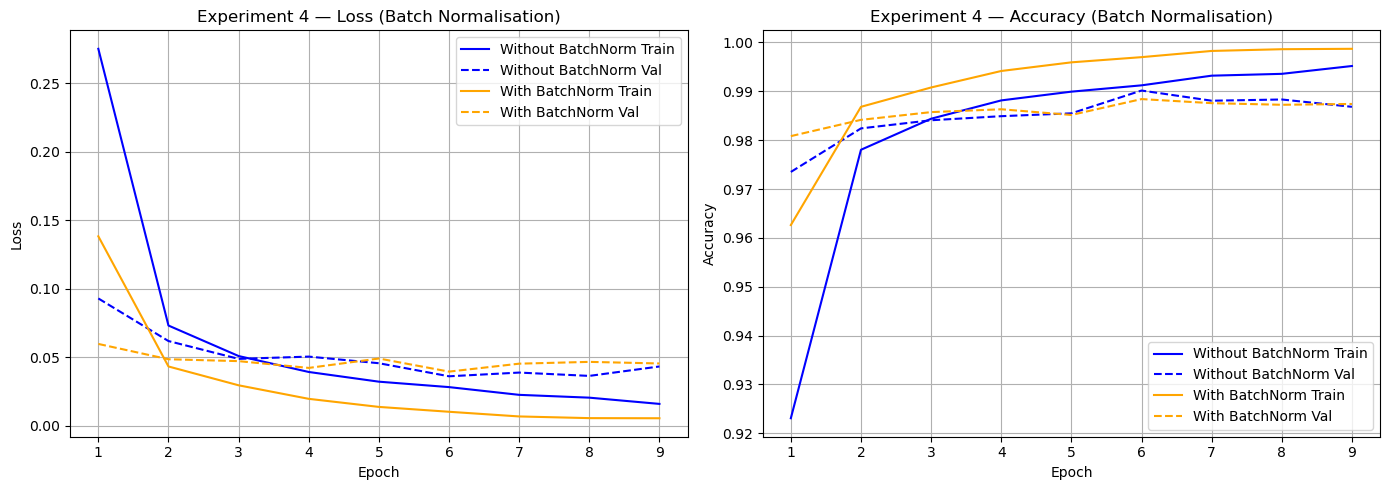

In [ ]:
class CNN_BatchNorm(nn.Module):
    def __init__(self, use_batchnorm=False):
        super(CNN_BatchNorm, self).__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32) if use_batchnorm else nn.Identity(),
            nn.ELU(alpha=1.0),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64) if use_batchnorm else nn.Identity(),
            nn.ELU(alpha=1.0),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128) if use_batchnorm else nn.Identity(),
            nn.ELU(alpha=1.0)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 128),
            nn.ELU(alpha=1.0),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.classifier(x)
        return x


# ── Train Both Variants ───────────────────────────────────────────────

exp4_results = {}

batchnorm_options = {
    'Without BatchNorm' : False,
    'With BatchNorm'    : True
}

for name, use_bn in batchnorm_options.items():
    print(f"\nTraining Exp 4 — {name}...")

    model_exp4     = CNN_BatchNorm(use_batchnorm=use_bn).to(device)
    optimizer_exp4 = optim.Adam(model_exp4.parameters(), lr=0.0001)
    scheduler_exp4 = optim.lr_scheduler.ReduceLROnPlateau(
                        optimizer_exp4, mode='min', patience=3, factor=0.1)
    es_exp4        = EarlyStopping(patience=3)

    tr_loss, v_loss, tr_acc, v_acc = train_model(
        model_exp4, train_loader, val_loader,
        criterion, optimizer_exp4, scheduler_exp4, es_exp4
    )

    exp4_results[name] = {
        'train_loss': tr_loss, 'val_loss'  : v_loss,
        'train_acc' : tr_acc,  'val_acc'   : v_acc,
        'model'     : model_exp4
    }

# ── Plot Overlaid Curves ──────────────────────────────────────────────

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors = ['blue', 'orange']

for (name, results), color in zip(exp4_results.items(), colors):
    epochs = range(1, len(results['train_loss']) + 1)
    ax1.plot(epochs, results['train_loss'], label=f'{name} Train', color=color)
    ax1.plot(epochs, results['val_loss'],   label=f'{name} Val',   color=color, linestyle='--')
    ax2.plot(epochs, results['train_acc'],  label=f'{name} Train', color=color)
    ax2.plot(epochs, results['val_acc'],    label=f'{name} Val',   color=color, linestyle='--')

ax1.set_title('Experiment 4 — Loss (Batch Normalisation)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

ax2.set_title('Experiment 4 — Accuracy (Batch Normalisation)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

> **Result:** Batch Normalisation produced the most dramatic improvement across all 
> experiments — faster convergence, lower training loss, and higher validation accuracy.
> The model with BatchNorm reached ~99.9% train and ~98.8% val accuracy, while the 
> model without plateaued earlier and triggered early stopping at epoch 9.
> This is consistent with Ioffe & Szegedy (2015).
>
> ✅ **Winner: With BatchNorm** — incorporated into the Final Best Model.

## 8. Final Best Model

Based on the systematic experiments, the optimal architecture combines all winning 
components from each experiment:

| Component | Choice | Source |
|---|---|---|
| Conv Depth | 3 Blocks (32 → 64 → 128 filters) | Experiment 1 |
| Activation | ELU (alpha=1.0) | Experiment 2 |
| Pooling | MaxPool2d (2×2) | Experiment 3 |
| Batch Norm | BatchNorm2d after each conv | Experiment 4 |

The final model is retrained from scratch using this optimal configuration.

Training Final Best Model...
Epoch [1/15] Train Loss: 0.1487 | Train Acc: 0.9598 | Val Loss: 0.0654 | Val Acc: 0.9812
Epoch [2/15] Train Loss: 0.0444 | Train Acc: 0.9869 | Val Loss: 0.0504 | Val Acc: 0.9856
Epoch [3/15] Train Loss: 0.0288 | Train Acc: 0.9911 | Val Loss: 0.0504 | Val Acc: 0.9844
Epoch [4/15] Train Loss: 0.0199 | Train Acc: 0.9940 | Val Loss: 0.0425 | Val Acc: 0.9872
Epoch [5/15] Train Loss: 0.0144 | Train Acc: 0.9958 | Val Loss: 0.0404 | Val Acc: 0.9886
Epoch [6/15] Train Loss: 0.0104 | Train Acc: 0.9971 | Val Loss: 0.0460 | Val Acc: 0.9867
EarlyStopping counter: 1/3
Epoch [7/15] Train Loss: 0.0069 | Train Acc: 0.9982 | Val Loss: 0.0441 | Val Acc: 0.9877
EarlyStopping counter: 2/3
Epoch [8/15] Train Loss: 0.0065 | Train Acc: 0.9980 | Val Loss: 0.0555 | Val Acc: 0.9850
EarlyStopping counter: 3/3
Early stopping triggered at epoch 8


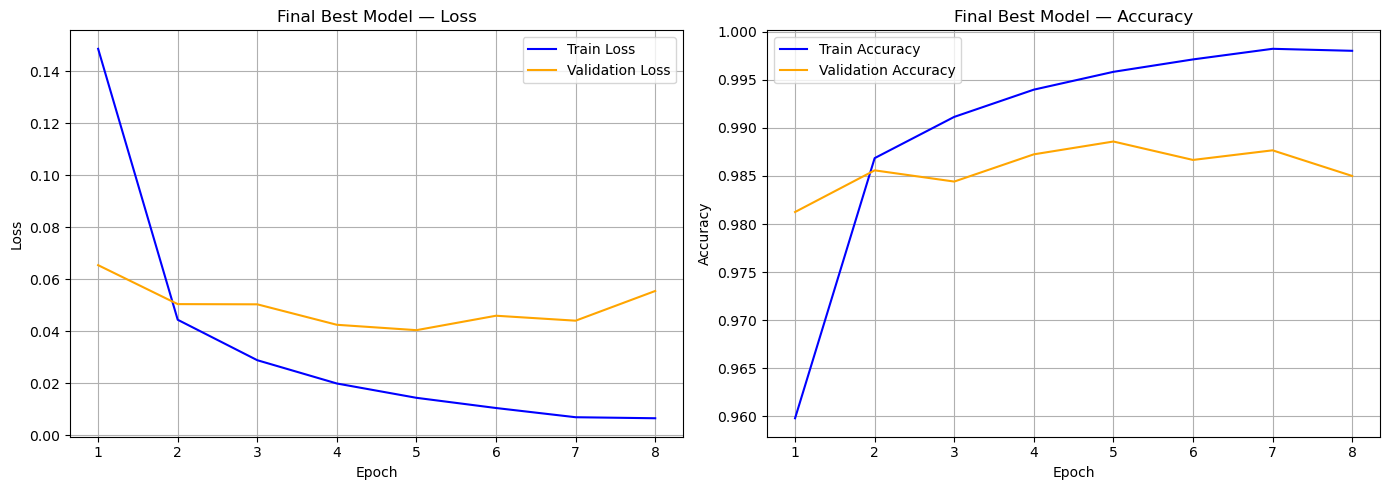

Final model saved!


In [ ]:
class FinalCNN(nn.Module):
    def __init__(self):
        super(FinalCNN, self).__init__()

        # Conv Block 1: 32 filters + BN + ELU + MaxPool
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ELU(alpha=1.0),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Conv Block 2: 64 filters + BN + ELU + MaxPool
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ELU(alpha=1.0),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Conv Block 3: 128 filters + BN + ELU
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ELU(alpha=1.0)
        )

        # Fully Connected Head
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 128),
            nn.ELU(alpha=1.0),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.classifier(x)
        return x


# ── Train Final Model ─────────────────────────────────────────────────
final_model     = FinalCNN().to(device)
final_optimizer = optim.Adam(final_model.parameters(), lr=0.0001)
final_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
                    final_optimizer, mode='min', patience=3, factor=0.1)
final_es        = EarlyStopping(patience=3)

print("Training Final Best Model...")
final_train_losses, final_val_losses, \
final_train_accs, final_val_accs = train_model(
    final_model, train_loader, val_loader,
    criterion, final_optimizer, final_scheduler, final_es
)

# ── Plot Final Learning Curves ────────────────────────────────────────
plot_learning_curves(
    final_train_losses, final_val_losses,
    final_train_accs,   final_val_accs,
    title='Final Best Model'
)

# ── Save Final Model ──────────────────────────────────────────────────
torch.save(final_model.state_dict(), './saved_models/final_model.pth')
print("Final model saved!")

> **Observation:** The final model shows mild overfitting from epoch 3 onwards,
> evidenced by the growing gap between training and validation curves. However, 
> with 98.5% validation accuracy this remains a strong result. Dropout could be 
> explored in future work to further close this gap.

## 9. Final Evaluation

The final model is evaluated on the **10,000 test images** for the first time.
This gives an unbiased measure of how well the model generalises to unseen data.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# ── Evaluate on Test Set ──────────────────────────────────────────────
final_model.eval()

test_loss     = 0.0
test_correct  = 0
test_total    = 0
all_preds     = []
all_labels    = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs        = final_model(images)
        loss           = criterion(outputs, labels)

        test_loss    += loss.item()
        _, predicted  = torch.max(outputs, 1)
        test_correct += (predicted == labels).sum().item()
        test_total   += labels.size(0)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

avg_test_loss = test_loss / len(test_loader)
avg_test_acc  = test_correct / test_total

print(f"Test Loss     : {avg_test_loss:.4f}")
print(f"Test Accuracy : {avg_test_acc:.4f} ({avg_test_acc*100:.2f}%)")
print()

# ── Classification Report ─────────────────────────────────────────────
class_names = [str(i) for i in range(10)]
report = classification_report(
    all_labels, all_preds,
    target_names=class_names
)
print("Classification Report:")
print(report)

Test Loss     : 0.0492
Test Accuracy : 0.9863 (98.63%)

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       1.00      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.98      0.98       982
           5       0.99      0.97      0.98       892
           6       0.98      0.99      0.98       958
           7       0.99      0.99      0.99      1028
           8       0.98      0.99      0.98       974
           9       0.97      0.98      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



### Confusion Matrix

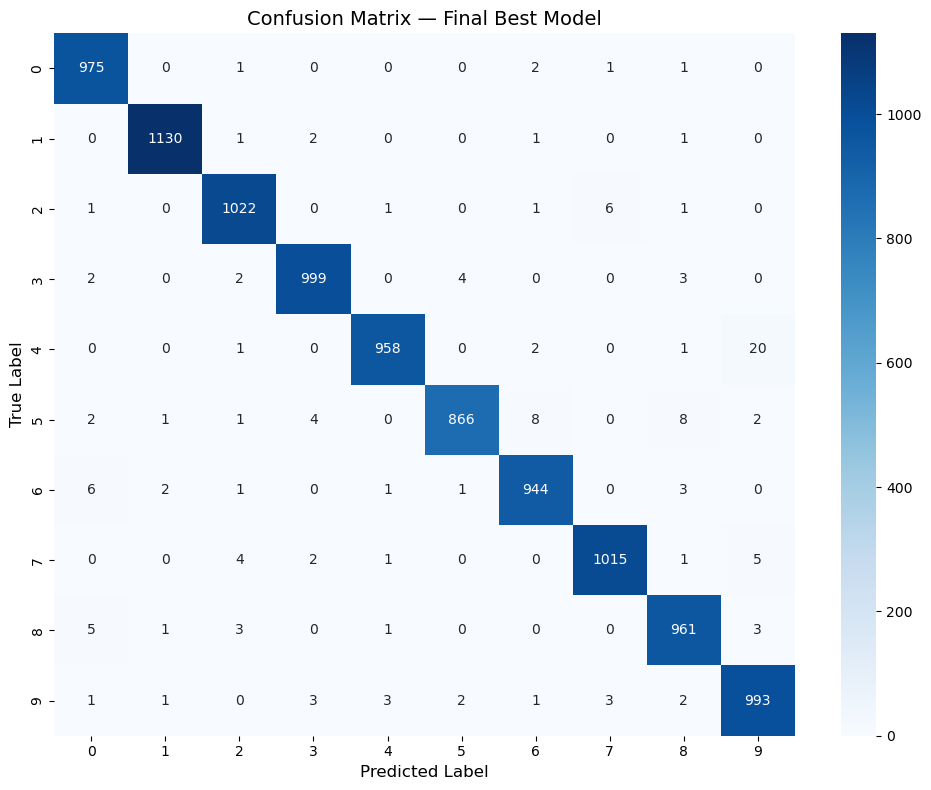

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

cm = confusion_matrix(all_labels, all_preds)

sns.heatmap(
    cm,
    annot      = True,
    fmt        = 'd',
    cmap       = 'Blues',
    xticklabels= class_names,
    yticklabels= class_names,
    ax         = ax
)

ax.set_title('Confusion Matrix — Final Best Model', fontsize=14)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)

plt.tight_layout()
plt.show()

> **Interpretation:** The diagonal dominance confirms strong overall performance.
> The most notable confusion is between digits **4 and 9** (20 instances), 
> which share similar upper loop structures in handwritten form. Other minor 
> confusions include **5 → 6** and **6 → 0**, both explainable by visual similarity.

### Sample Predictions & Misclassified Samples

Visual inspection of model predictions on test images, showing the predicted label 
and model confidence score for each sample.

- 🟢 **Green** — correct prediction
- 🔴 **Red** — incorrect prediction

Sample Predictions:


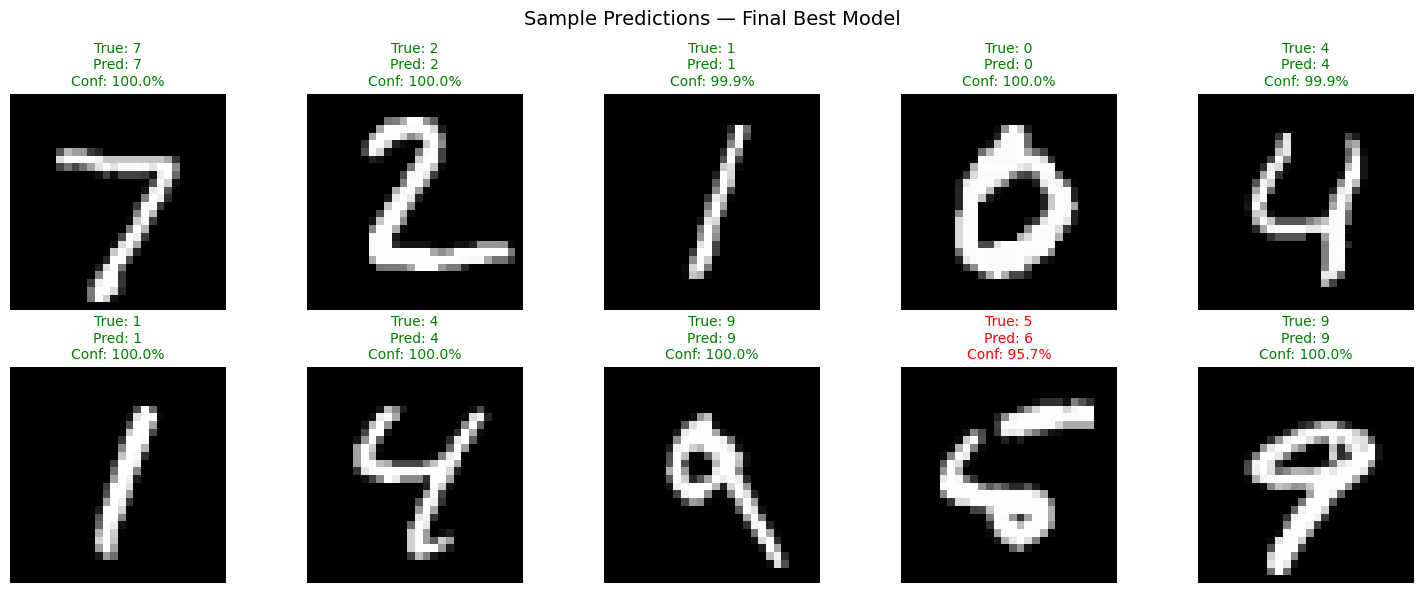

Misclassified Samples:


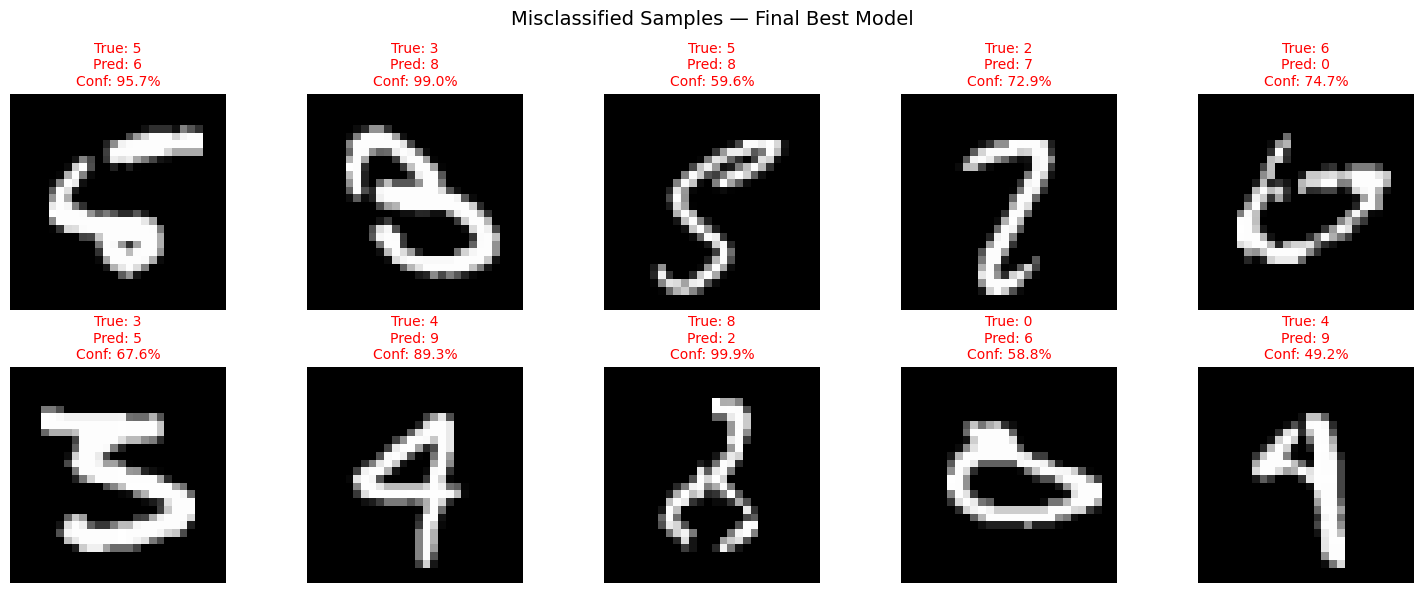

In [ ]:
import torch.nn.functional as F

# ── Helper Function ───────────────────────────────────────────────────
def show_predictions(model, test_loader, device, num_images=10):
    
    model.eval()
    images_shown = 0

    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    fig.suptitle('Sample Predictions — Final Best Model', fontsize=14)
    axes = axes.flatten()

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs        = model(images)

            # Convert logits to probabilities
            probabilities  = F.softmax(outputs, dim=1)
            confidences, predicted = torch.max(probabilities, 1)

            for i in range(len(images)):
                if images_shown >= num_images:
                    break

                # Get image, true label, prediction and confidence
                img        = images[i].cpu().squeeze().numpy()
                true_label = labels[i].cpu().item()
                pred_label = predicted[i].cpu().item()
                confidence = confidences[i].cpu().item() * 100

                # Display image
                axes[images_shown].imshow(img, cmap='gray')
                axes[images_shown].axis('off')

                # Green title = correct, Red = wrong
                color = 'green' if pred_label == true_label else 'red'
                axes[images_shown].set_title(
                    f'True: {true_label}\n'
                    f'Pred: {pred_label}\n'
                    f'Conf: {confidence:.1f}%',
                    color=color, fontsize=10
                )
                images_shown += 1

            if images_shown >= num_images:
                break

    plt.tight_layout()
    plt.show()


# ── Show Correct Predictions ──────────────────────────────────────────
print("Sample Predictions:")
show_predictions(final_model, test_loader, device, num_images=10)


# ── Show Misclassified Samples ────────────────────────────────────────
def show_misclassified(model, test_loader, device, num_images=10):

    model.eval()
    misclassified_imgs   = []
    misclassified_true   = []
    misclassified_pred   = []
    misclassified_conf   = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs        = model(images)
            probabilities  = F.softmax(outputs, dim=1)
            confidences, predicted = torch.max(probabilities, 1)

            # Find misclassified
            wrong_mask = predicted != labels
            for i in range(len(images)):
                if wrong_mask[i] and len(misclassified_imgs) < num_images:
                    misclassified_imgs.append(images[i].cpu().squeeze().numpy())
                    misclassified_true.append(labels[i].cpu().item())
                    misclassified_pred.append(predicted[i].cpu().item())
                    misclassified_conf.append(confidences[i].cpu().item() * 100)

            if len(misclassified_imgs) >= num_images:
                break

    # Plot misclassified
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    fig.suptitle('Misclassified Samples — Final Best Model', fontsize=14)
    axes = axes.flatten()

    for i in range(num_images):
        axes[i].imshow(misclassified_imgs[i], cmap='gray')
        axes[i].axis('off')
        axes[i].set_title(
            f'True: {misclassified_true[i]}\n'
            f'Pred: {misclassified_pred[i]}\n'
            f'Conf: {misclassified_conf[i]:.1f}%',
            color='red', fontsize=10
        )

    plt.tight_layout()
    plt.show()


print("Misclassified Samples:")
show_misclassified(final_model, test_loader, device, num_images=10)

In [ ]:
# ── Emergency Save Cell ───────────────────────────────────────────────
import os

# Force save to Task1 folder explicitly
save_dir = r'D:\GitHub\self\DeepLearning2\Task1\saved_models'
os.makedirs(save_dir, exist_ok=True)

print(f"Saving to: {save_dir}")

# Save all models
torch.save(model.state_dict(), 
           os.path.join(save_dir, 'baseline.pth'))
torch.save(final_model.state_dict(), 
           os.path.join(save_dir, 'final_model.pth'))

for name, results in exp1_results.items():
    safe_name = name.replace(' ', '_')
    torch.save(results['model'].state_dict(),
               os.path.join(save_dir, f'exp1_{safe_name}.pth'))

for name, results in exp2_results.items():
    torch.save(results['model'].state_dict(),
               os.path.join(save_dir, f'exp2_{name}.pth'))

for name, results in exp3_results.items():
    torch.save(results['model'].state_dict(),
               os.path.join(save_dir, f'exp3_{name}.pth'))

for name, results in exp4_results.items():
    safe_name = name.replace(' ', '_')
    torch.save(results['model'].state_dict(),
               os.path.join(save_dir, f'exp4_{safe_name}.pth'))

print("All models saved! Files:")
for f in os.listdir(save_dir):
    print(f"  {f}")

Saving to: D:\GitHub\self\DeepLearning2\Task1\saved_models
All models saved! Files:
  baseline.pth
  exp1_1_Block.pth
  exp1_2_Blocks.pth
  exp1_3_Blocks.pth
  exp2_ELU.pth
  exp2_LeakyReLU.pth
  exp2_ReLU.pth
  exp3_AvgPool.pth
  exp3_MaxPool.pth
  exp4_Without_BatchNorm.pth
  exp4_With_BatchNorm.pth
  final_model.pth


## 10. Conclusion

This investigation systematically explored four architectural components of a CNN 
trained on the MNIST dataset, leading to a final model achieving **98.63% test accuracy**.

| Experiment | Winner | Val Accuracy Improvement |
|---|---|---|
| Conv Depth | 3 Blocks | 98.4% → 99.3% |
| Activation | ELU | 99.2% → 99.4% |
| Pooling | MaxPool | Clear margin over AvgPool |
| BatchNorm | With BN | Fastest convergence |

The evidence-based approach confirmed that deeper networks, smooth activation 
functions, dominant feature preservation through MaxPool, and training stabilisation 
through BatchNorm collectively produce the strongest results for handwritten digit 
classification.

**Future work** could explore Dropout regularisation to address mild overfitting, 
data augmentation to improve robustness, and residual connections to enable even 
deeper architectures.